In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5
G_lo = 20.0

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
1.2455164256645084 29.51009880871049


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:112: RuntimeWarning: invalid value encountered in divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


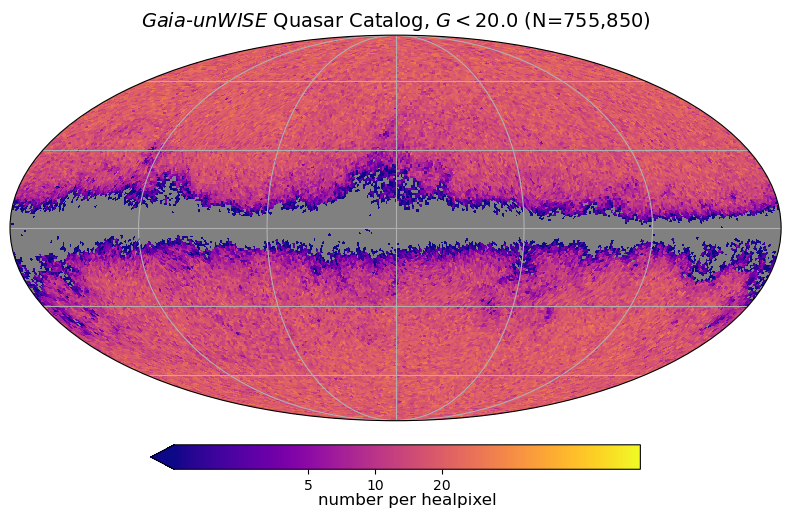

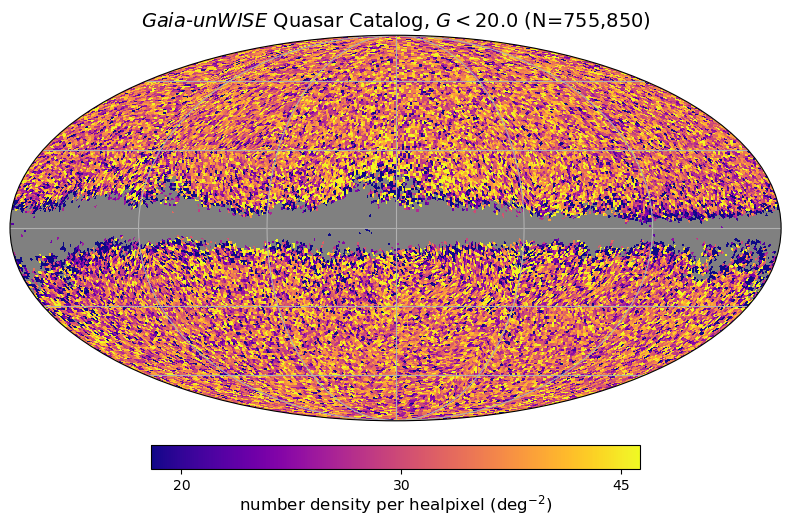

In [8]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, 
                                                                               plot = True, cbar_ticks_selfunc = [20, 30, 45])

In [9]:
# cmap = sns.color_palette("rocket", as_cmap = True)
# cmap

cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [10]:
zbin_array = [0,1,2,3]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(zbin_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)))
cmaps = [cmap_red, cmap_blue]

In [11]:
# def absolute(m, z):
#     return m+5-5*np.log10(quaia.luminosity_dist(z, units = 'pc').value) # d is in parsecs

In [12]:
# G = absolute(tab_datalo['phot_g_mean_mag'], tab_datalo['redshift_quaia'])

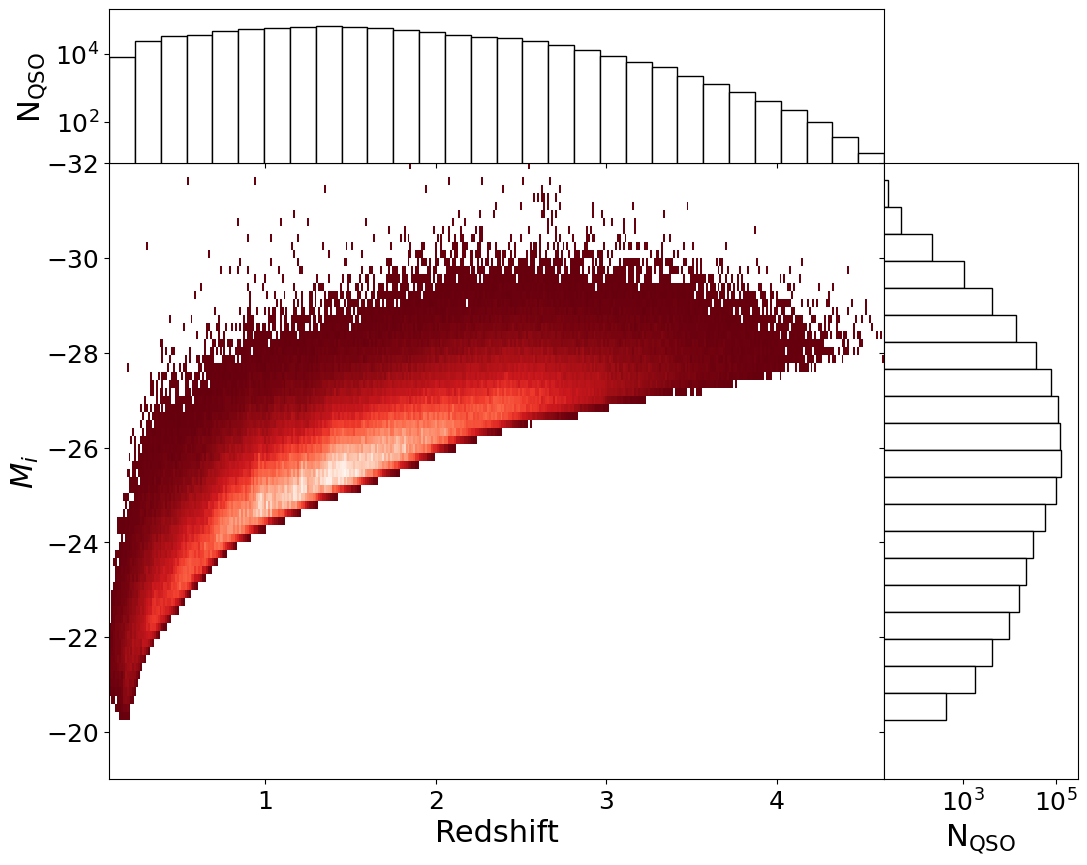

In [16]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'], tab_datalo['M_i'], cmap = cmap_reds, bins = 400, cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('Redshift')
ax1.set_ylim(-19, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datalo['redshift_quaia'], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datalo['M_i'], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 120)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
2.7814783357416957 49.932632992383304


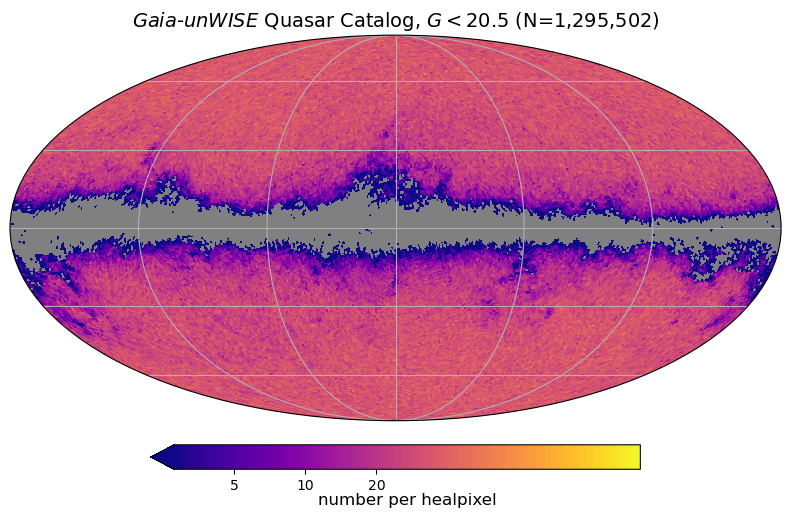

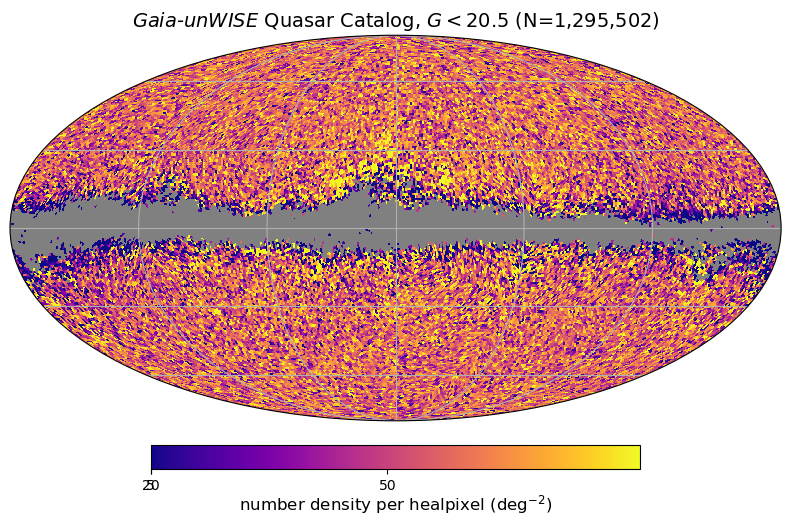

In [17]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, 
                                                                               plot = True)

In [18]:
# G = absolute(tab_datahi['phot_g_mean_mag'], tab_datahi['redshift_quaia'])

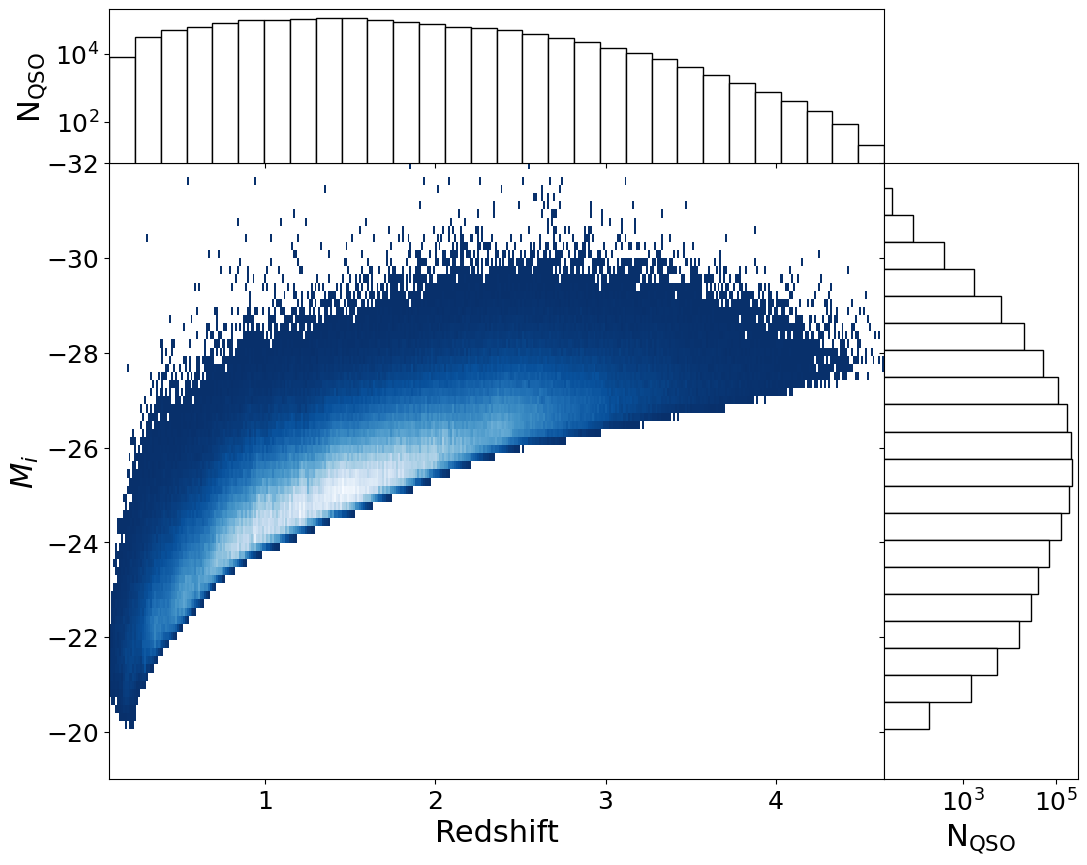

In [19]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'], tab_datahi['M_i'], cmap = cmap_blues, bins = 400, cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('Redshift')
ax1.set_ylim(-19, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 120)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

In [20]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

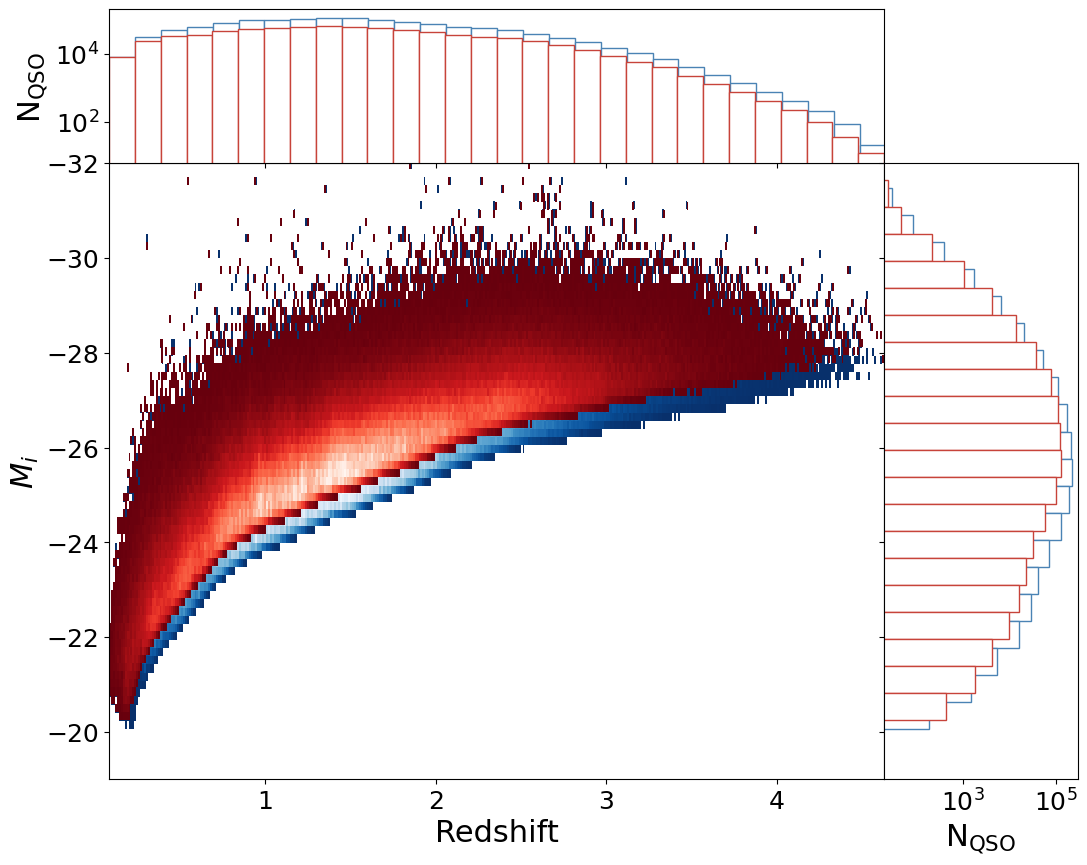

In [22]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

# G_hi = quaia.absolute(tab_datahi)
# G_lo = quaia.absolute(tab_datalo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'], tab_datahi['M_i'], cmap = cmap_blues, bins = 400, cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'], tab_datalo['M_i'], cmap = cmap_reds, bins = 400, cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('Redshift')
ax1.set_ylim(-19, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 120)
ax3.hist(tab_datalo['M_i'], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 120)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## Define a function

In [23]:
def zbins(G, zsplit, zbin, plot = False):
    
    if zsplit>1:
        fn_datahi_zbin0 = '../data/quaia_G{}_zsplit{}bin{}.fits'.format(G, zsplit, zbin)
        fn_randhi_zbin0 = '../data/randoms/random_G{}_zsplit{}bin{}_10x.fits'.format(G, zsplit, zbin)
        fn_selhi_zbin0 = '../data/maps/selection_function_NSIDE64_G{}_zsplit{}bin{}.fits'.format(G, zsplit, zbin)
    else:
        fn_datahi_zbin0 = '../data/quaia_G{}.fits'.format(G)
        fn_randhi_zbin0 = '../data/randoms/random_G{}_10x.fits'.format(G)
        fn_selhi_zbin0 = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    # print(fn_datahi_zbin0)
    # print(fn_randhi_zbin0)
    # print(fn_selhi_zbin0)

    # parameters
    selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)

    # quasar data catalog
    tab_datahi_zbin0 = Table.read(fn_datahi_zbin0)
    pixel_indices_datahi_zbin0 = hp.ang2pix(NSIDE, tab_datahi_zbin0['ra'], tab_datahi_zbin0['dec'], lonlat=True)
    mask_datahi_zbin0 = selfunc_hi_zbin0[pixel_indices_datahi_zbin0]>=0.5 

    # impose zbin and selfunc mask on data
    tab_datahi_mask_zbin0 = tab_datahi_zbin0[mask_datahi_zbin0]
    
    # record N in each bin
    N_datahi_mask_zbin0 = len(tab_datahi_mask_zbin0)
    
    # random catalog
    tab_randhi_zbin0 = Table.read(fn_randhi_zbin0)
    pixel_indices_randhi_zbin0 = hp.ang2pix(NSIDE, tab_randhi_zbin0['ra'], tab_randhi_zbin0['dec'], lonlat=True)

    # select where the randoms in each zbin pass the selfunc mask
    mask_randhi_zbin0 = selfunc_hi_zbin0[pixel_indices_randhi_zbin0]>=0.5

    # assign redshifts to randoms in each zbin, mimicking the distribution of data in each zbin that pass the selfunc mask
    tab_randhi_mask_zbin0 = tab_randhi_zbin0[mask_randhi_zbin0]
    N_randhi_mask_zbin0 = len(tab_randhi_mask_zbin0)
    key_zbin0 = quaia.z_dist(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, np.full(N_datahi_mask_zbin0, True), 
                             np.full(N_randhi_mask_zbin0, True), N_datahi_mask_zbin0, N_randhi_mask_zbin0, plot = plot, 
                             mask_type = mask_type+'_zbin{}'.format(zbin))
    
    return tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0

## $\xi(s)$

In [24]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

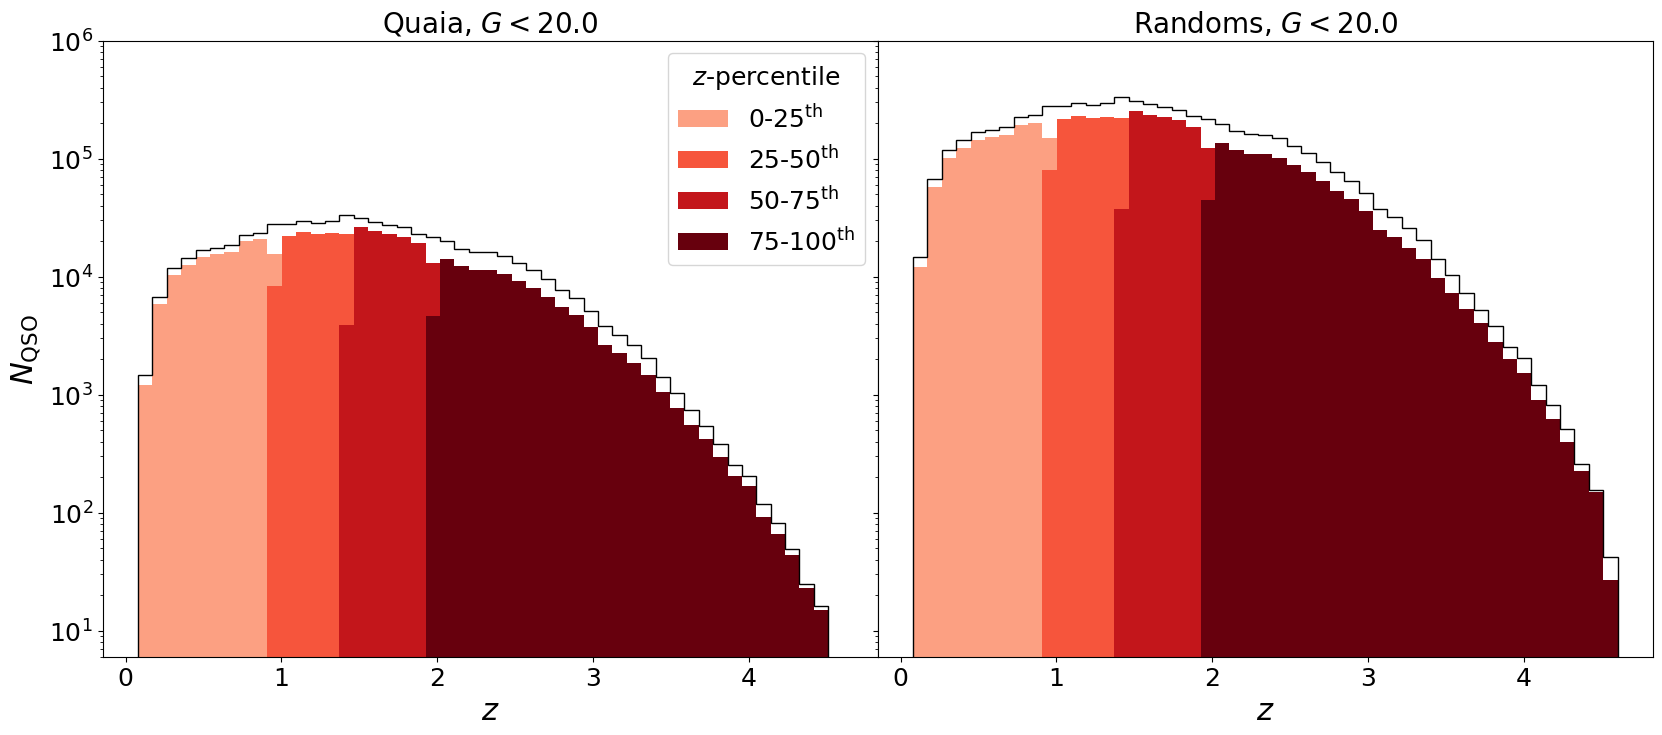

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

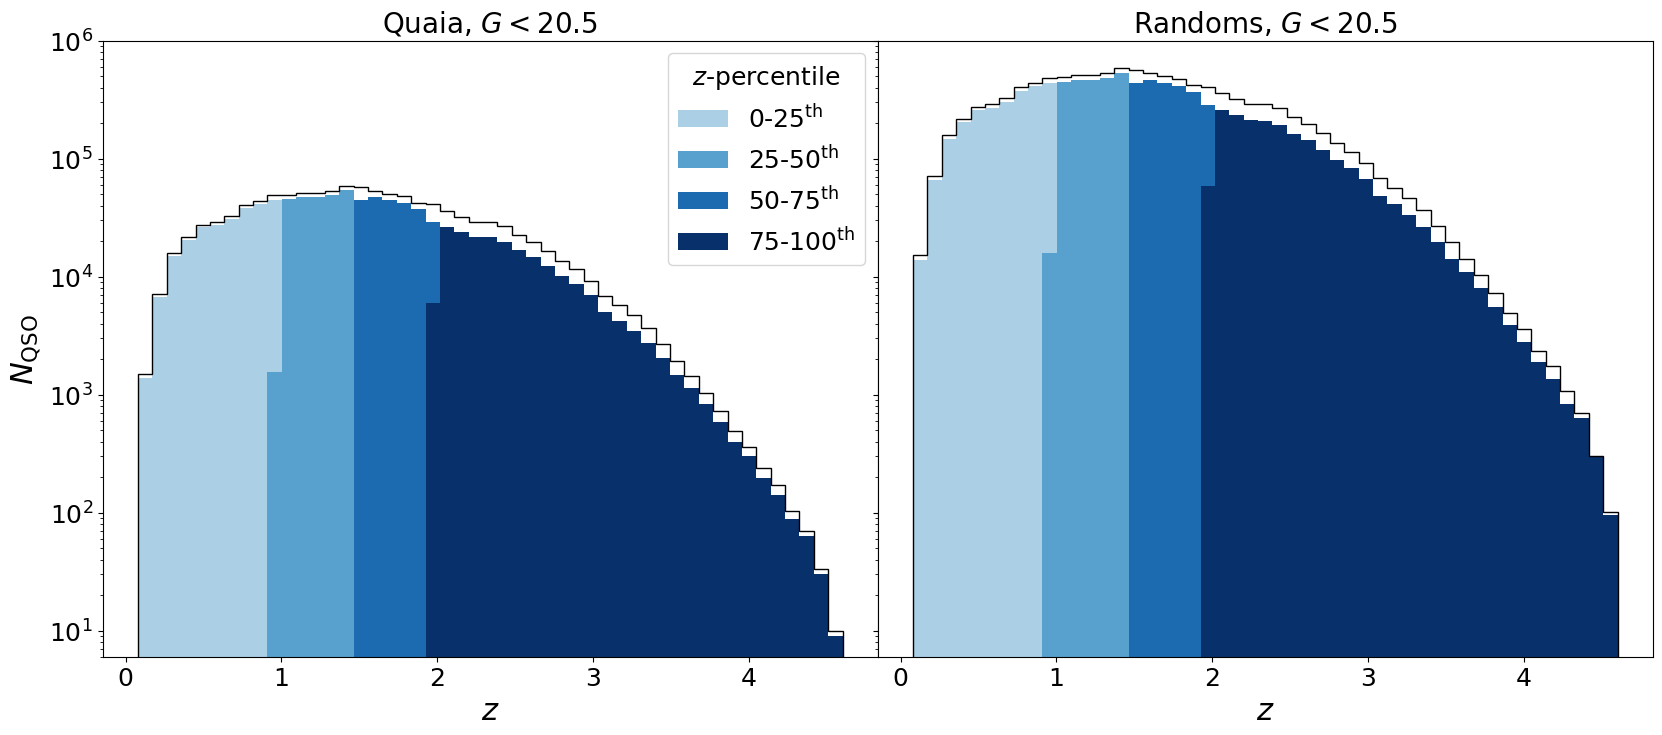

In [27]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = {20.0: [], 20.5: []}
for G, cmap in zip([20.0, 20.5], cmaps):

    fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G)
    selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    fn_datahi = '../data/quaia_G{}.fits'.format(G)
    tab_datahi = Table.read(fn_datahi)
    pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
    mask_datahi = selfunc_hi[pixel_indices_datahi]>=0.5

    # plot!
    fig = plt.figure(figsize = (20, 8))
    gs = gridspec.GridSpec(1, 2, wspace = 0)

    ax1 = fig.add_subplot(gs[0])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[1])

    # for comparison purposes
    fn_randhi = '../data/randoms/random_G{}_10x.fits'.format(G)
    tab_randhi = Table.read(fn_randhi)
    pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
    mask_randhi = selfunc_hi[pixel_indices_randhi]>=0.5
    N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
    N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
    quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
             color = 'black')

    for zbin, label in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, len(zbin_array), 
                                                                                                                  zbin)
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = label, bins = bins, color = cmap[zbin])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_'+mask_type+'_zbin{}'.format(zbin)], label = label,
                 bins = bins, color = cmap[zbin])
        
        cf[G].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))
        
    ax1.set_xlabel('$z$')
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,1e6)
    ax1.set_title('Quaia, $G<{}$'.format(G))
    ax1.legend(title='$z$-percentile', title_fontsize = 18)

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,1e6)
    ax2.set_title('Randoms, $G<{}$'.format(G))
    ax2.set_yticklabels([])
    plt.show()

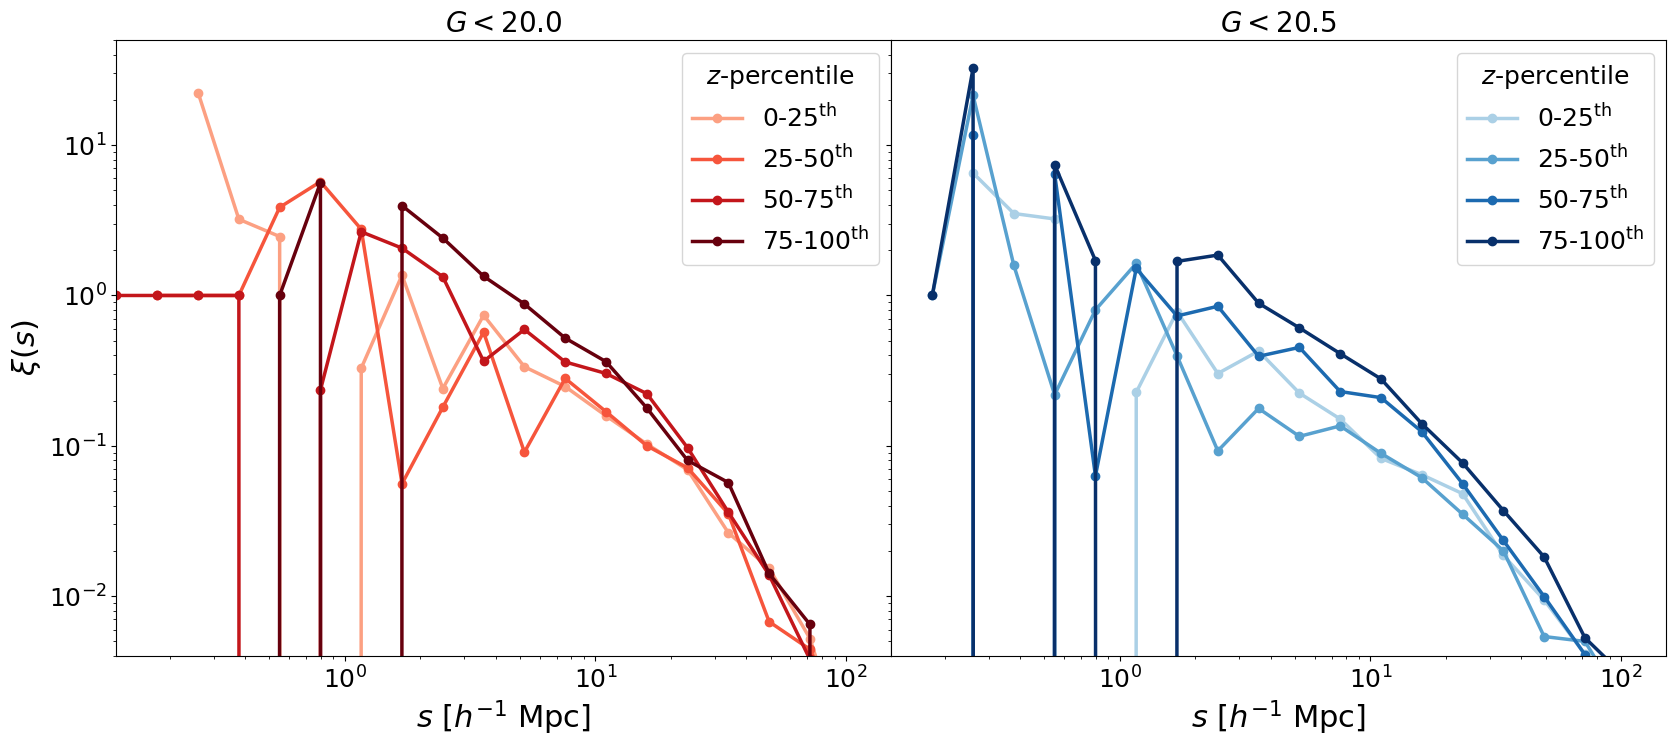

In [28]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin, label in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][zbin], marker = 'o', label = label, linewidth = 2.5, color = cmaps[i][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

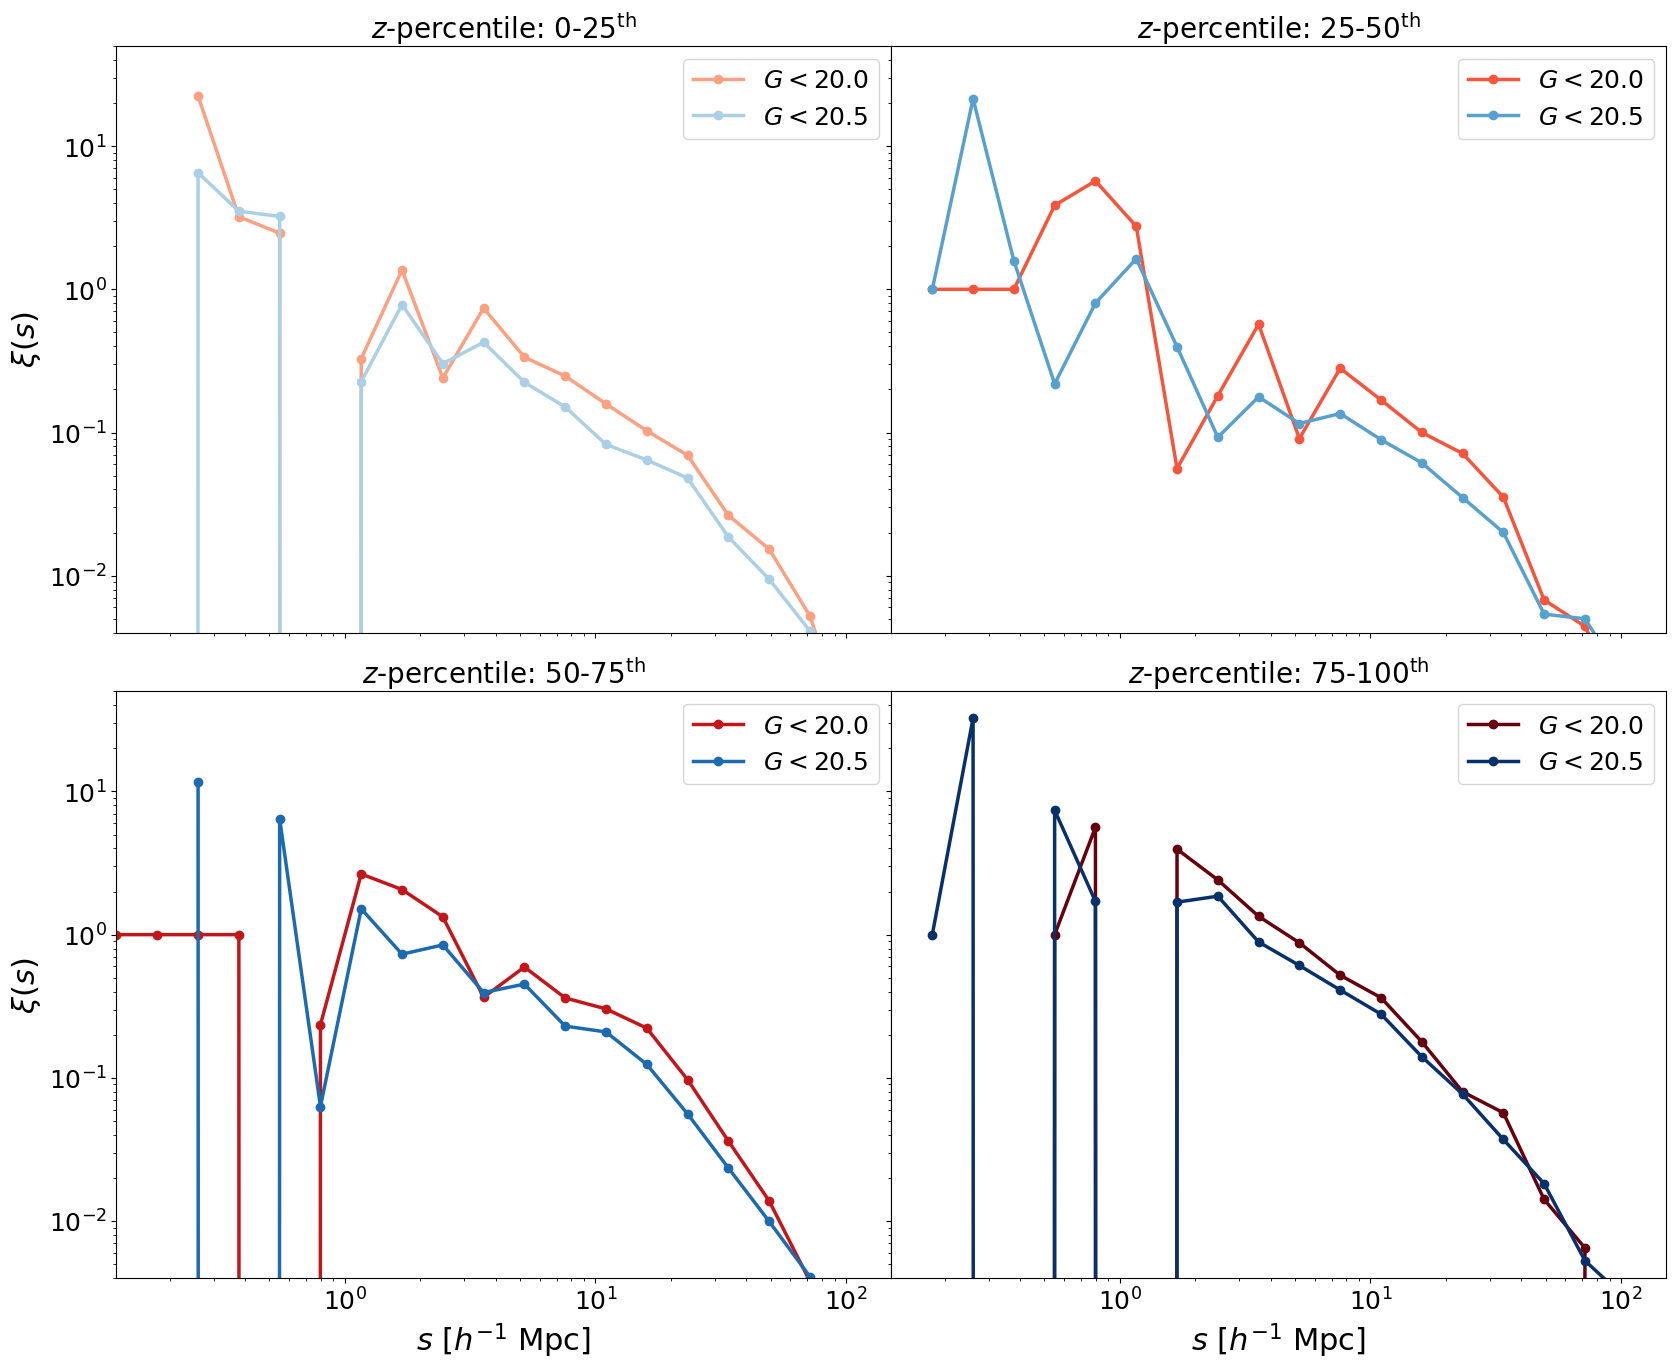

In [29]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin, title in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
    ax1 = fig.add_subplot(gs[zbin])
    for G, cmap in zip([20.0, 20.5], cmaps):
        ax1.plot(quaia.recenter(rbins), cf[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[zbin])
        ax1.set_title('$z$-percentile: {}'.format(title))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(4e-3, 5e1)
        if zbin>1:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])
        # if zbin==0:
        ax1.legend()

plt.show()

## $w_p(r_p)$

In [30]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [31]:
pimax = 80 # 40 # 5000.0 # 40.0

In [33]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, len(zbin_array), 
                                                                                                                  zbin)
        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

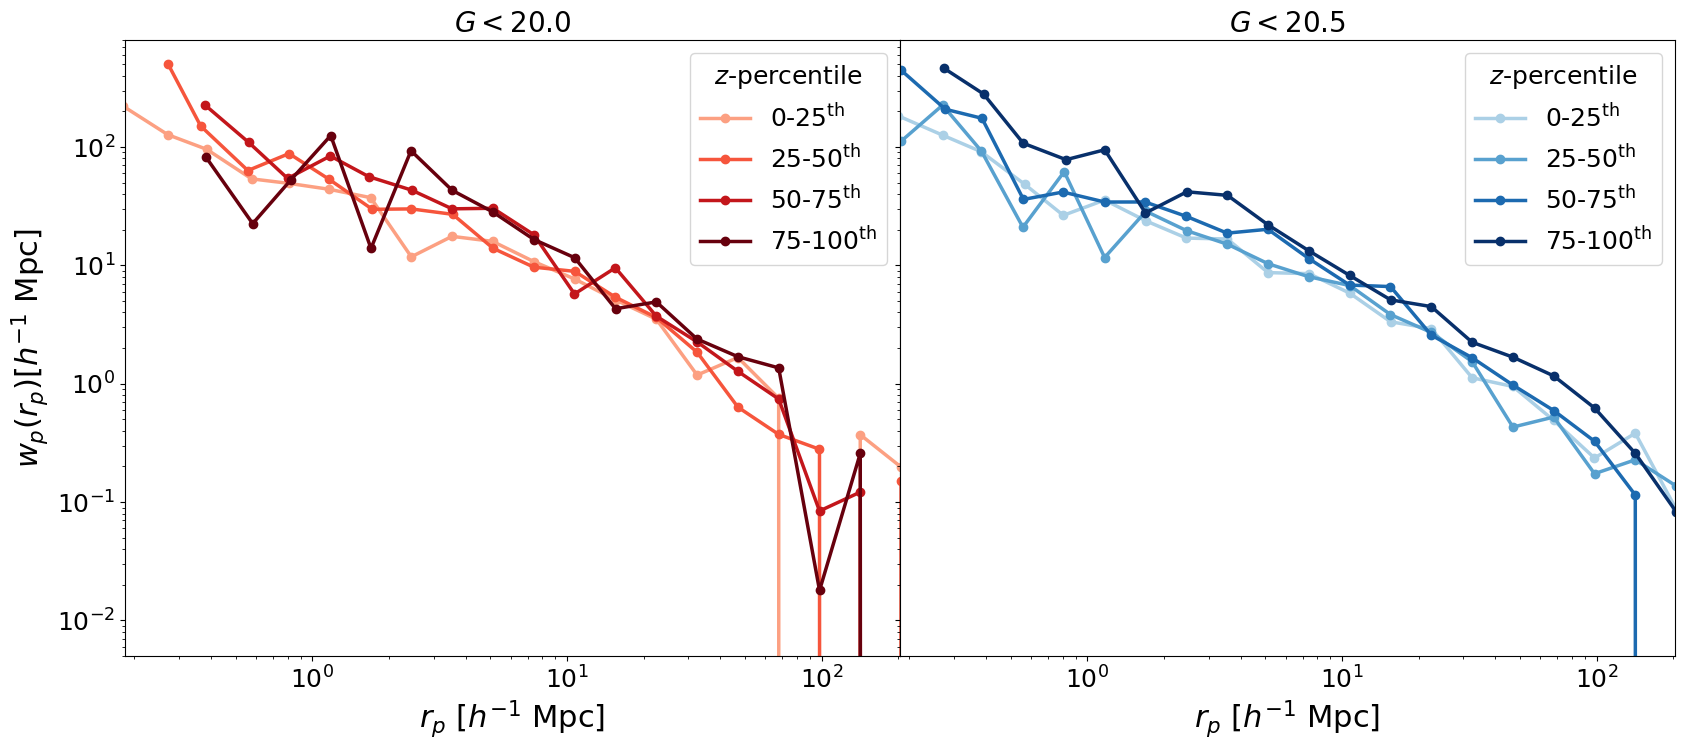

In [34]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin, label in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])

plt.show()

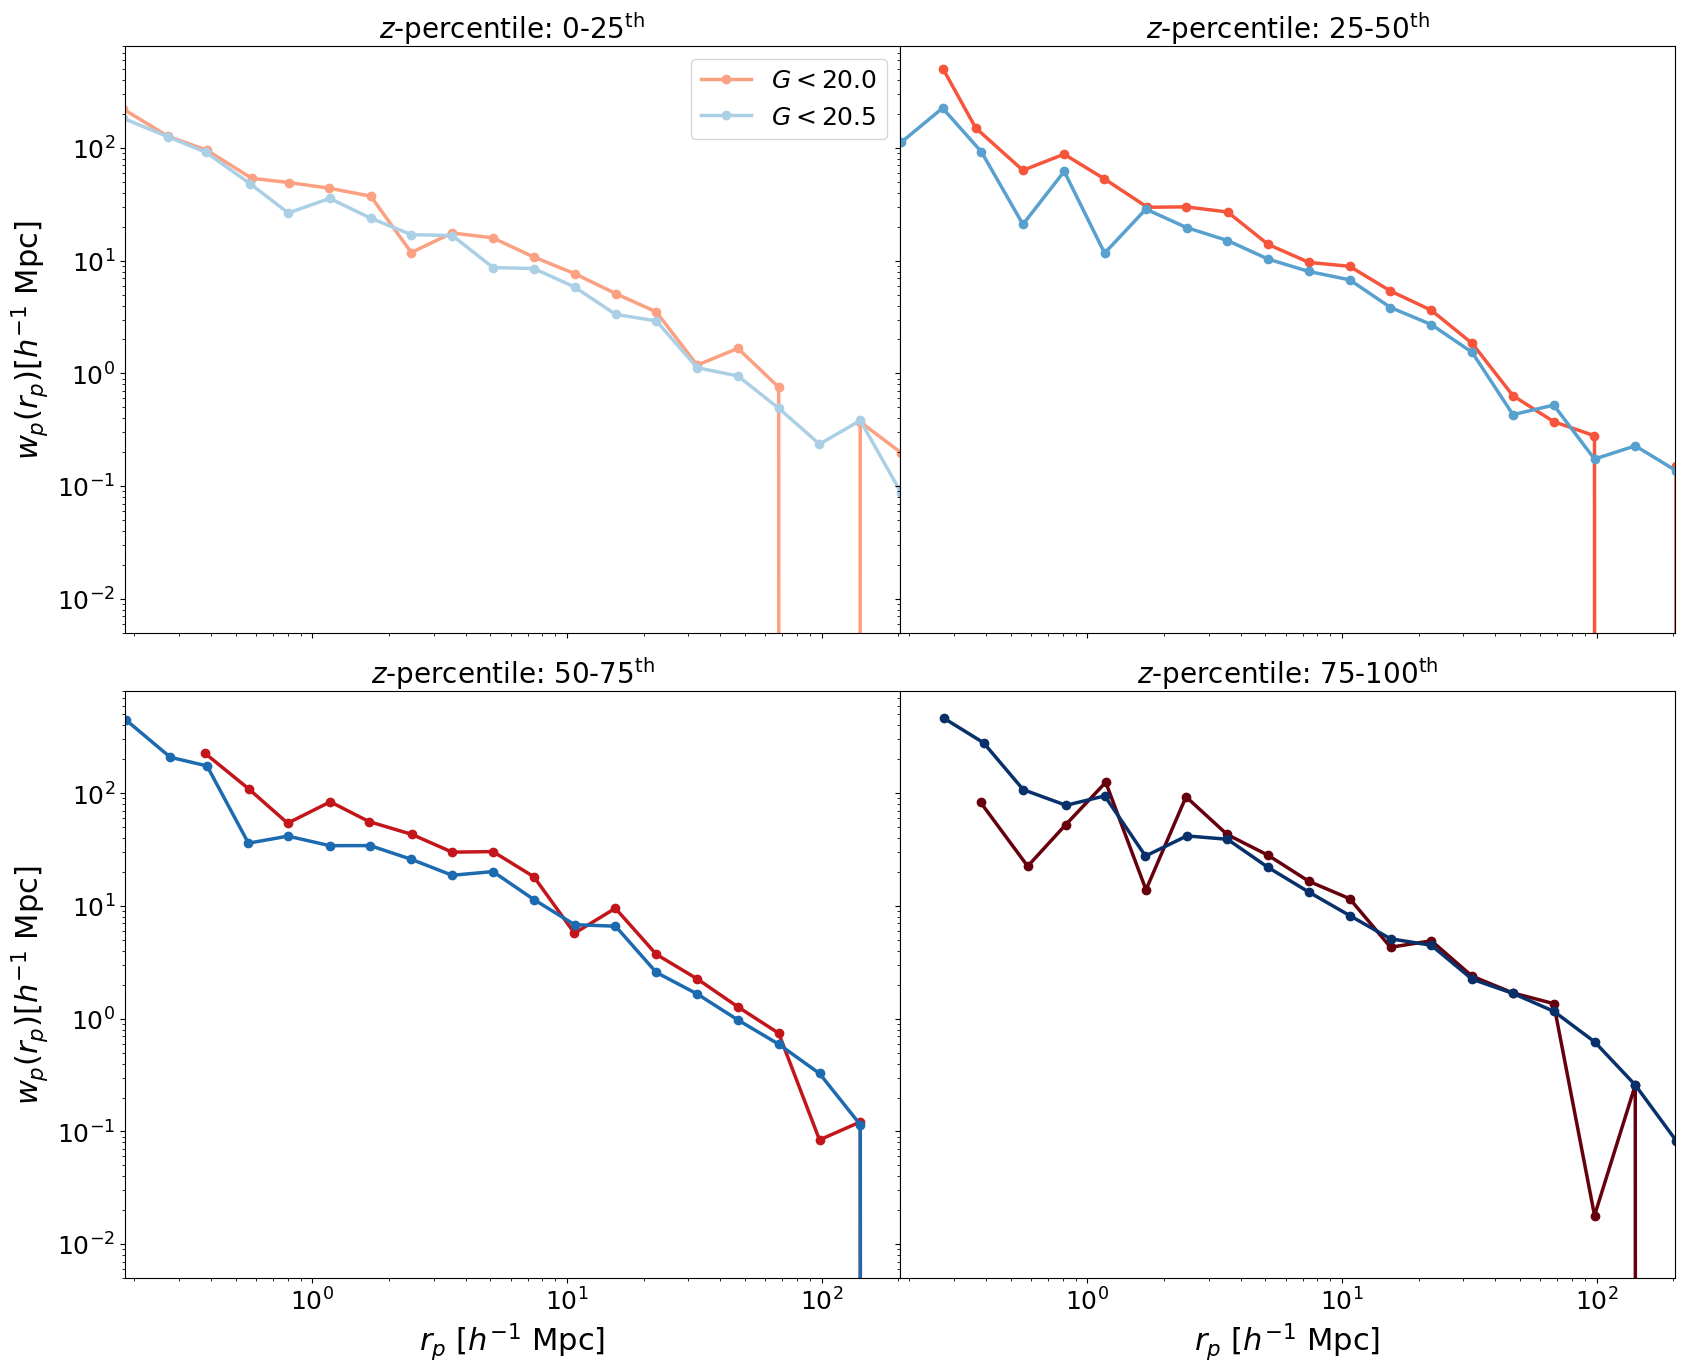

In [35]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin, title in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
    ax1 = fig.add_subplot(gs[zbin])
    for G, cmap in zip([20.0, 20.5], cmaps):
        ax1.plot(rpavg[G][zbin], wp[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[zbin])
        ax1.set_title('$z$-percentile: {}'.format(title))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-3, 8e2)
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
        else:
            ax1.set_yticklabels([])
        if zbin==0:
            ax1.legend()

plt.show()

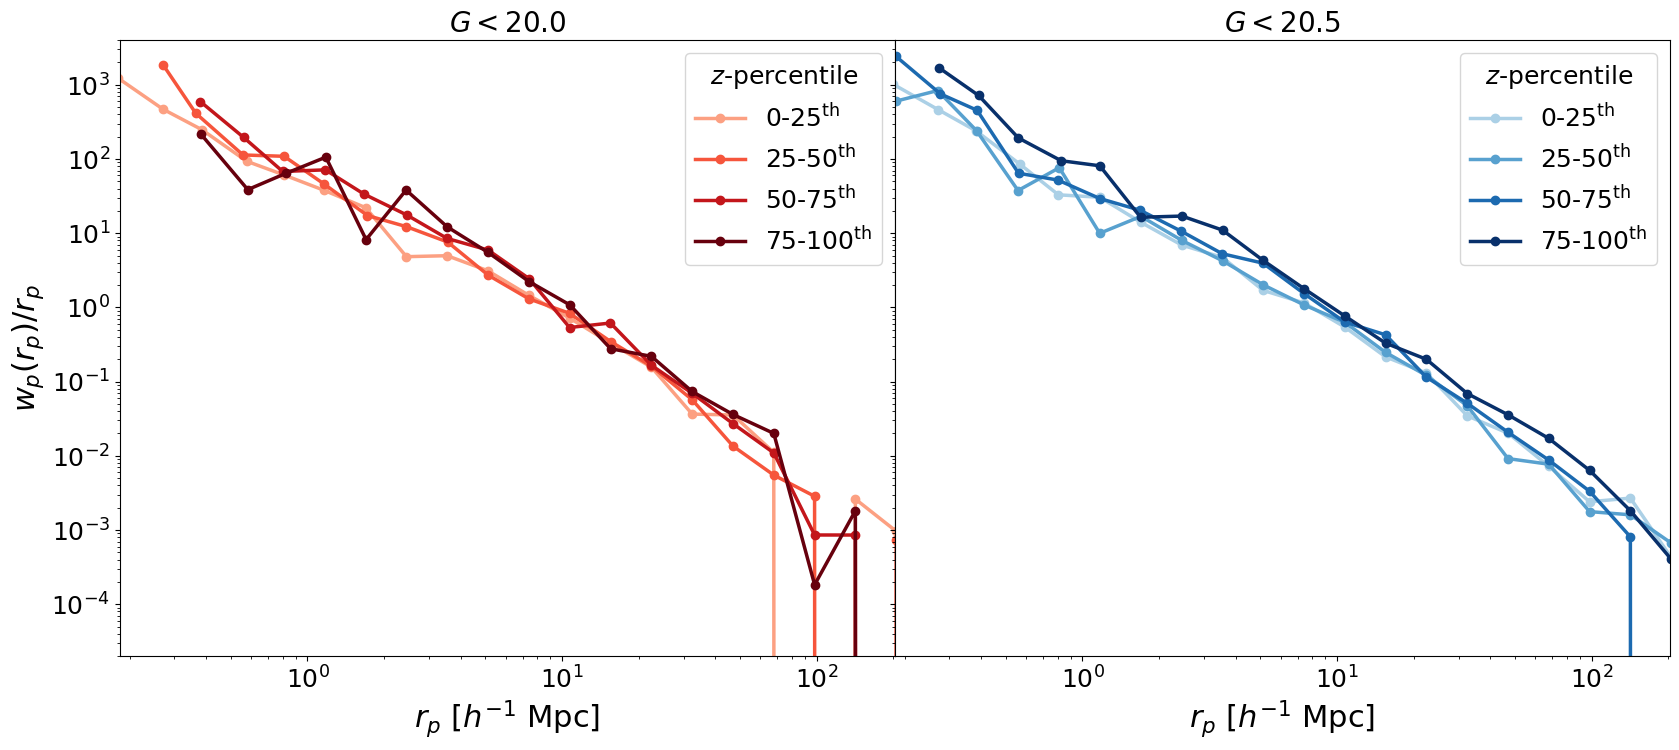

In [36]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin, label in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin]/rpavg[G_array[i]][zbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-5, 4e3)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])

plt.show()

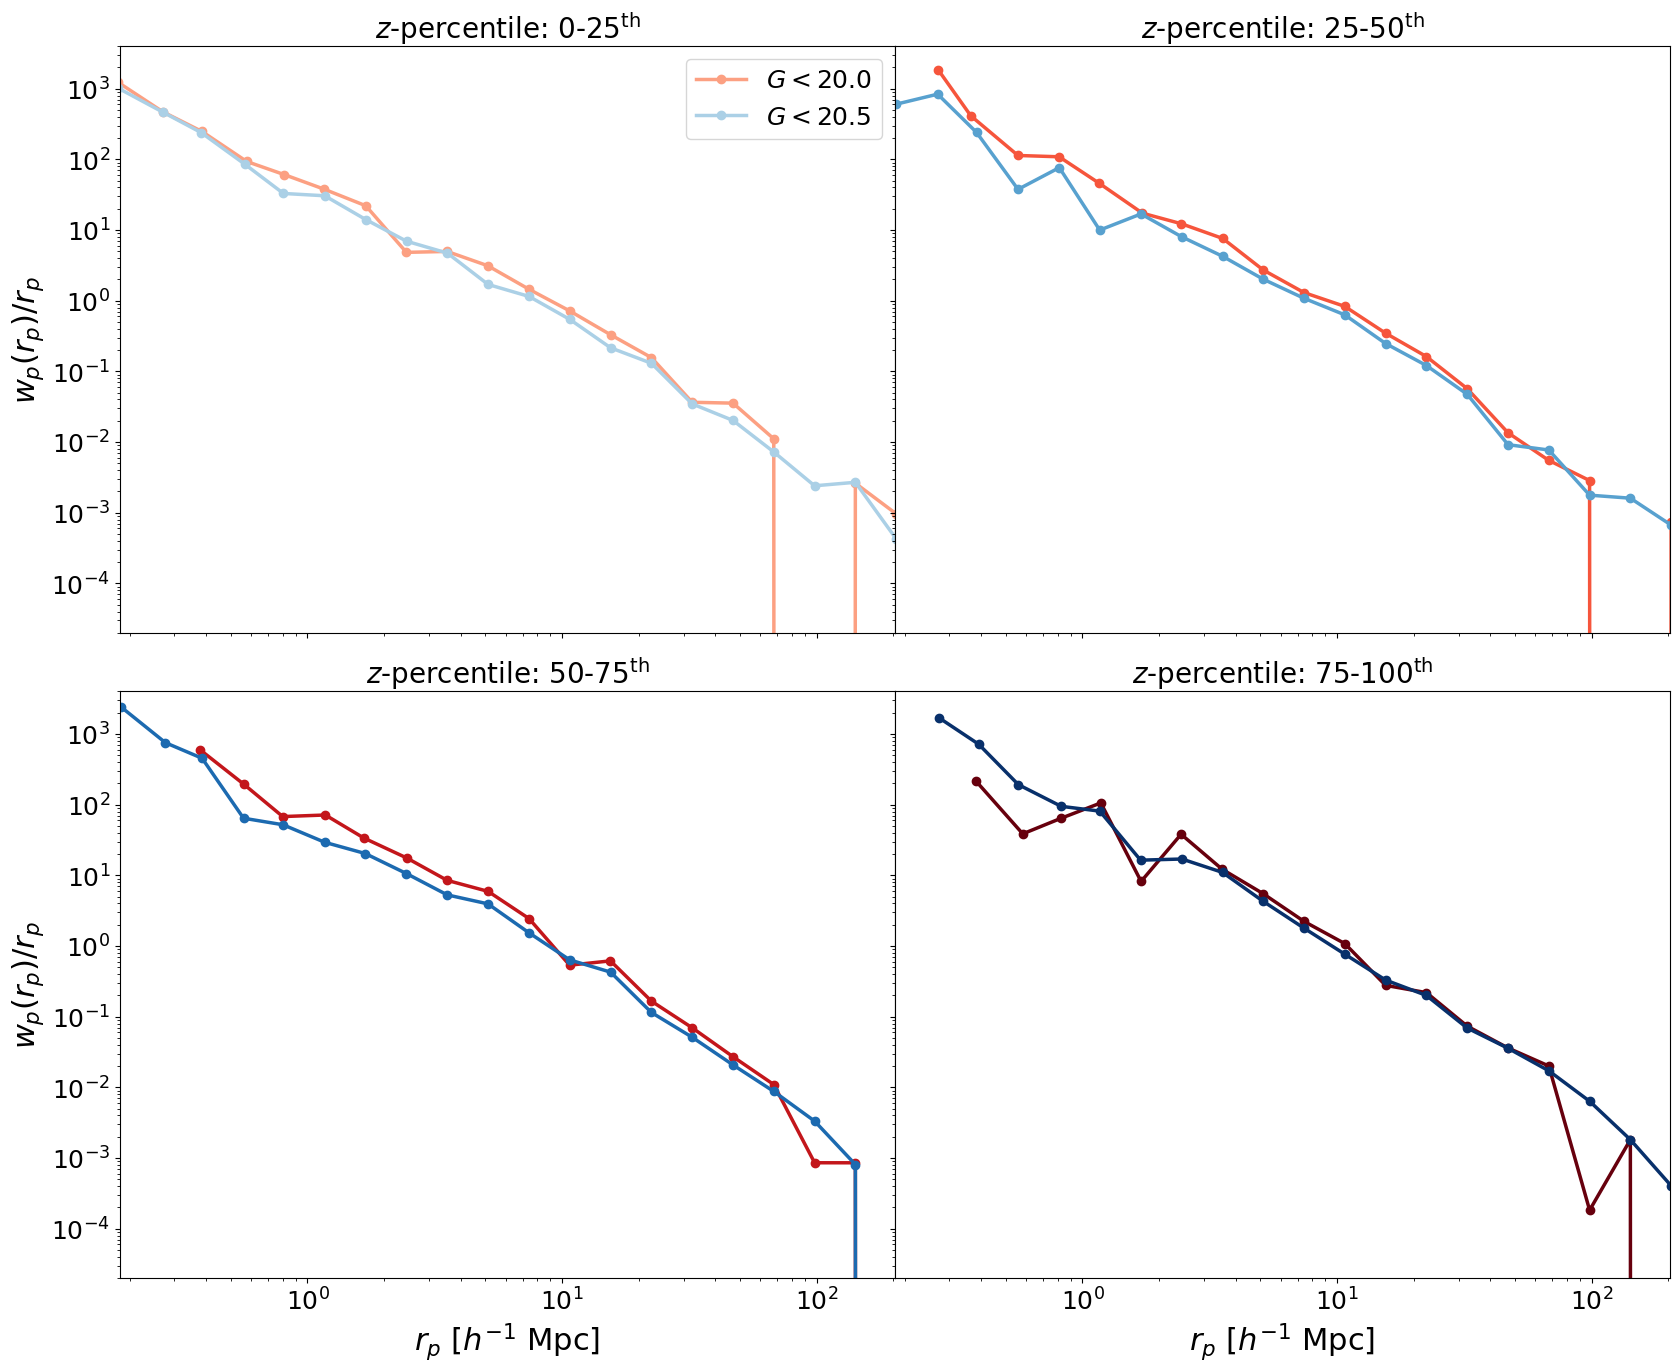

In [37]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin, title in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
    ax1 = fig.add_subplot(gs[zbin])
    for G, cmap in zip([20.0, 20.5], cmaps):
        ax1.plot(rpavg[G][zbin], wp[G][zbin]/rpavg[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[zbin])
        ax1.set_title('$z$-percentile: {}'.format(title))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-5, 4e3)
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if zbin==0:
            ax1.legend()

plt.show()

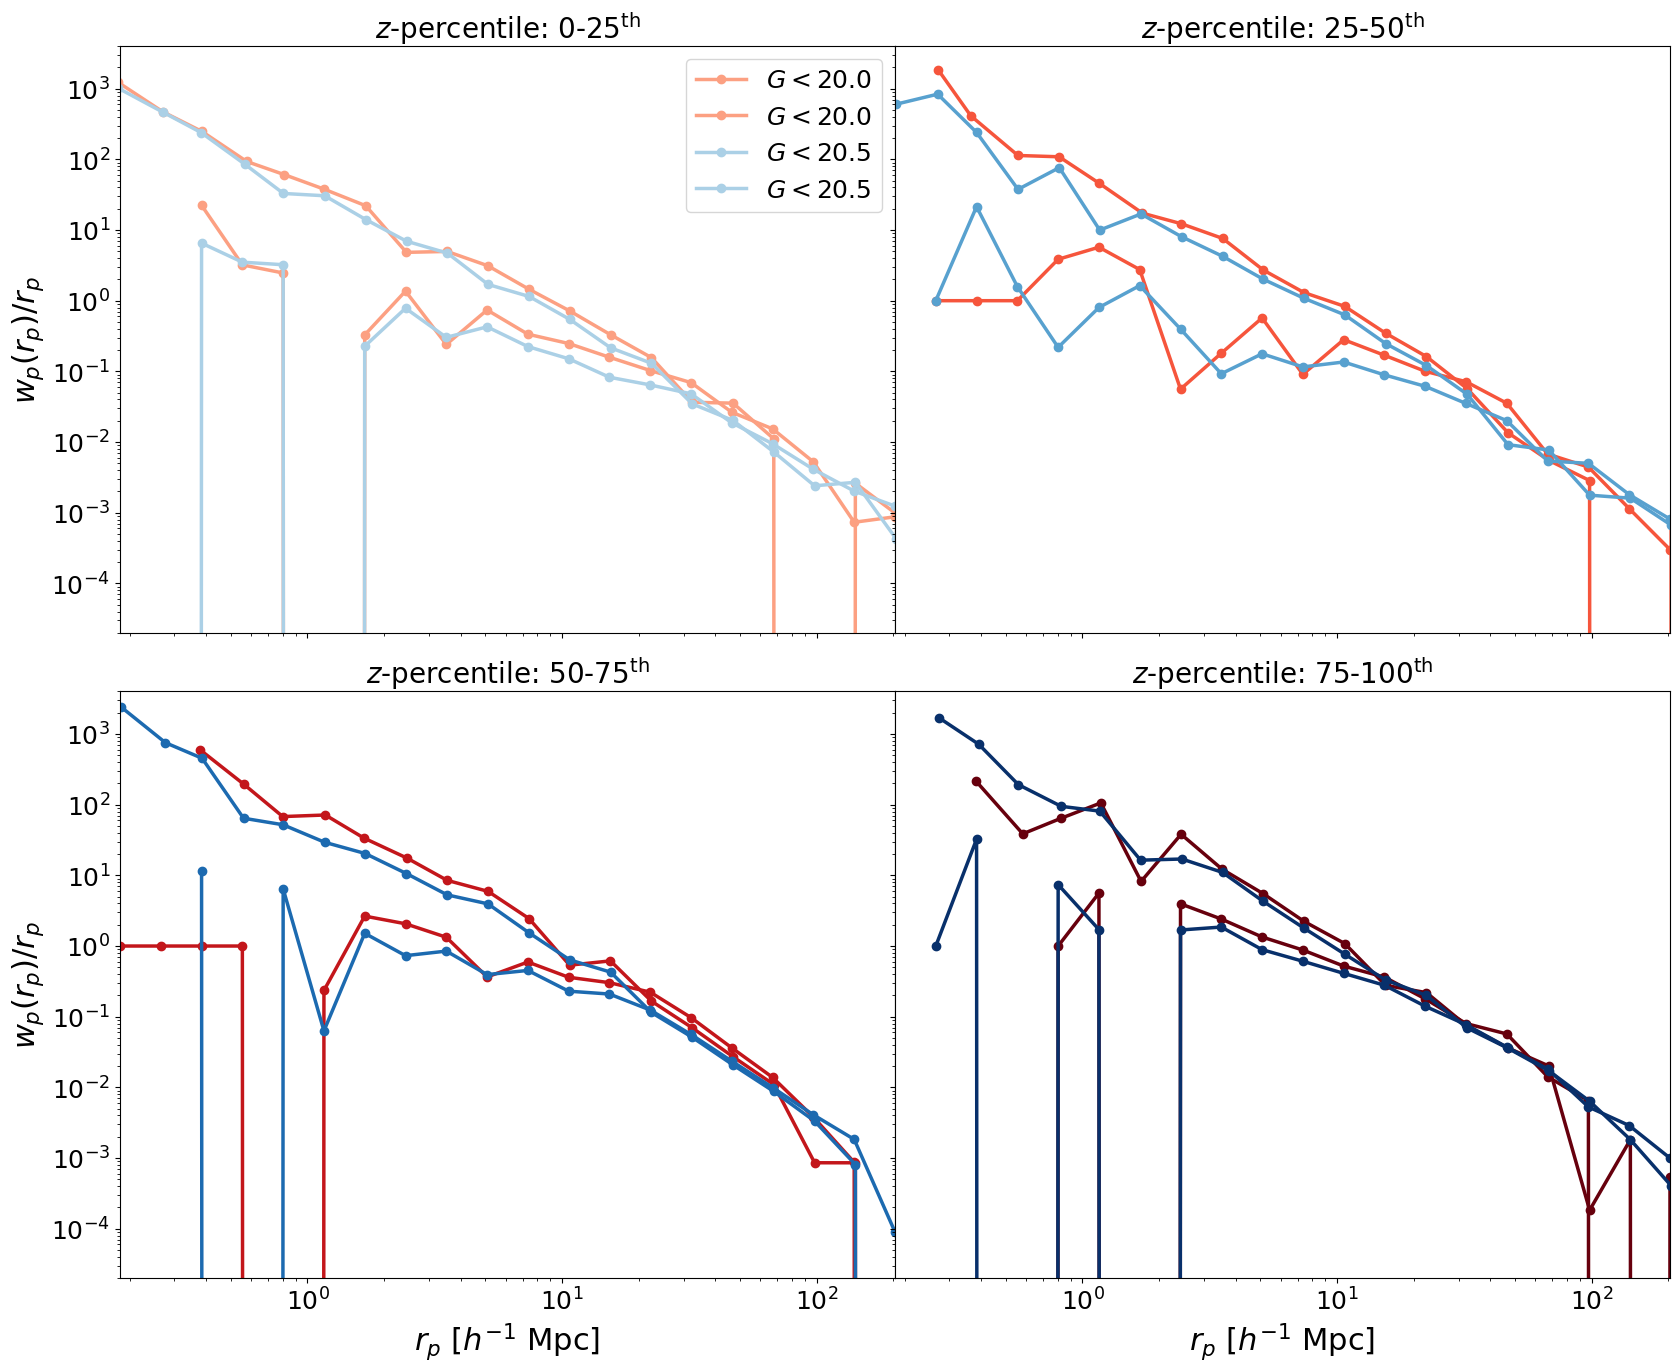

In [38]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin, title in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
    ax1 = fig.add_subplot(gs[zbin])
    for G, cmap in zip([20.0, 20.5], cmaps):
        ax1.plot(rpavg[G][zbin], wp[G][zbin]/rpavg[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[zbin])
        ax1.plot(quaia.recenter(rbins), cf[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[zbin])
        ax1.set_title('$z$-percentile: {}'.format(title))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(2e-5, 4e3)
        if zbin>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w_p(r_p)/r_p$")
        else:
            ax1.set_yticklabels([])
        if zbin==0:
            ax1.legend()

plt.show()

## Debug

In [29]:
# plot data
bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
zbin_array = [0]
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, len(zbin_array), 
                                                                                                                  zbin)
        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


In [ ]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

G_array = [20.0, 20.5]
i=0
ax1 = fig.add_subplot(gs[i])
for i in range(len(G_array)):
    # i=0
    # ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin], marker = 'o', label = '$G<{}$'.format(G_array[i]), linewidth = 2.5,
                 color = np.mean(cmaps[i], axis = 0))
ax1.set_title('$z$-percentile: 0-100th')
ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_ylim(5e-3, 8e2)
ax1.legend()
# if i==0:
ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
# else:
    # ax1.set_yticklabels([])

plt.show()

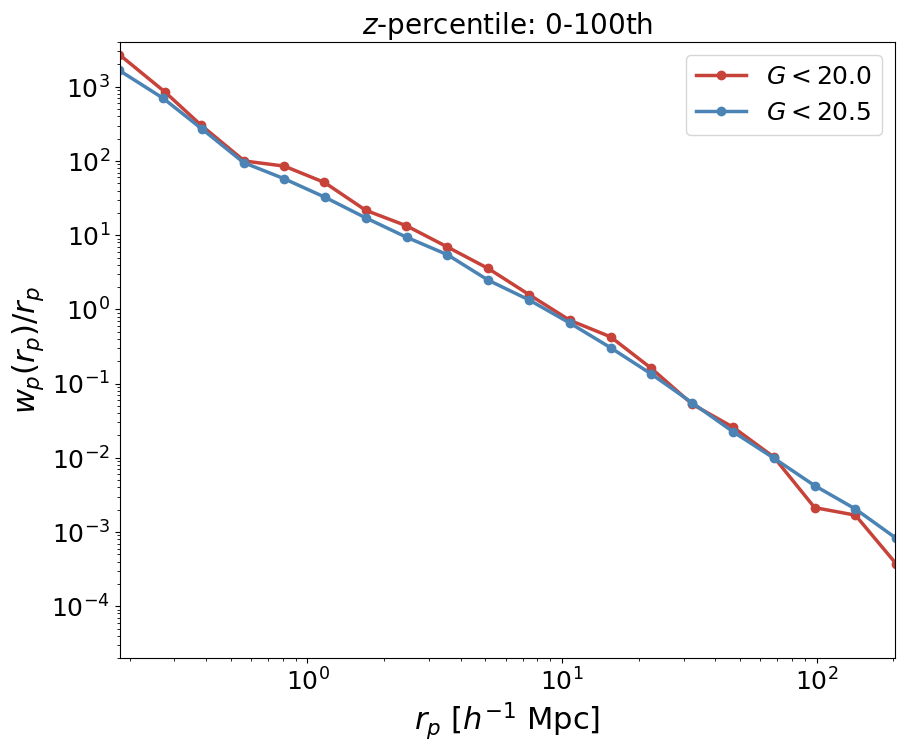

In [30]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

G_array = [20.0, 20.5]
i=0
ax1 = fig.add_subplot(gs[i])
for i in range(len(G_array)):
    # i=0
    # ax1 = fig.add_subplot(gs[i])
    for zbin in zbin_array:
        ax1.plot(rpavg[G_array[i]][zbin], wp[G_array[i]][zbin]/rpavg[G_array[i]][zbin], marker = 'o', 
                 label = '$G<{}$'.format(G_array[i]), linewidth = 2.5, color = np.mean(cmaps[i], axis = 0))
ax1.set_title('$z$-percentile: 0-100th')
ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
if scale == 'log':
    ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_ylim(2e-5, 4e3)
ax1.legend()
# if i==0:
ax1.set_ylabel(r"$w_p(r_p)/r_p$")
# else:
    # ax1.set_yticklabels([])

plt.show()

## $w(\theta)$

In [31]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [32]:
# plot data
wtheta = {20.0: [], 20.5: []}
zbin_array = [0,1,2,3]
for G in [20.0, 20.5]:

    for zbin in zbin_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = zbins(G, len(zbin_array), 
                                                                                                                  zbin)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                           N_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endia

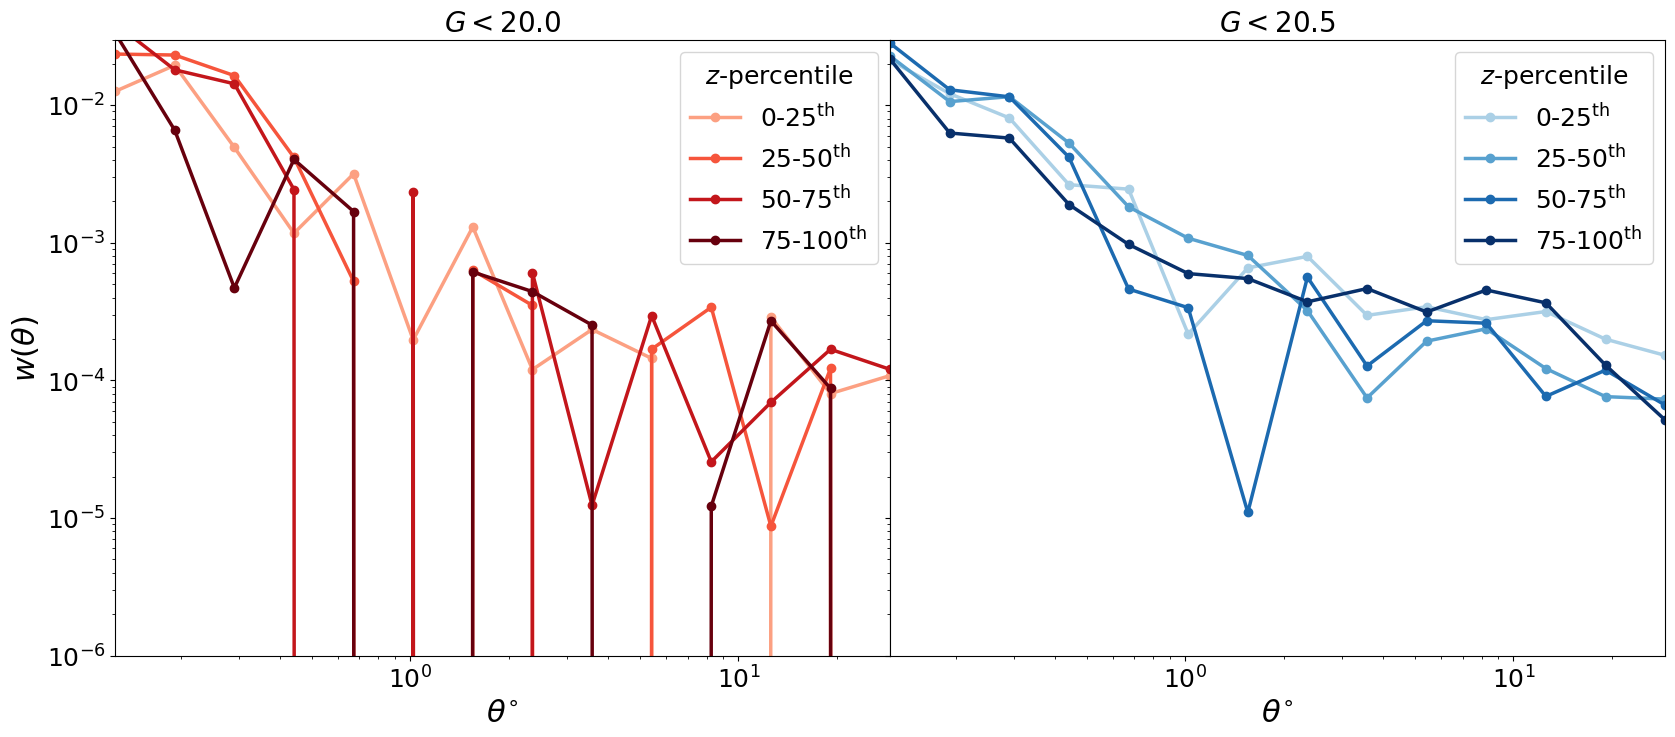

In [53]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for zbin, label in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][zbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][zbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$\theta^{\circ}$')
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.legend(title='$z$-percentile', title_fontsize = 18)
        if i==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()

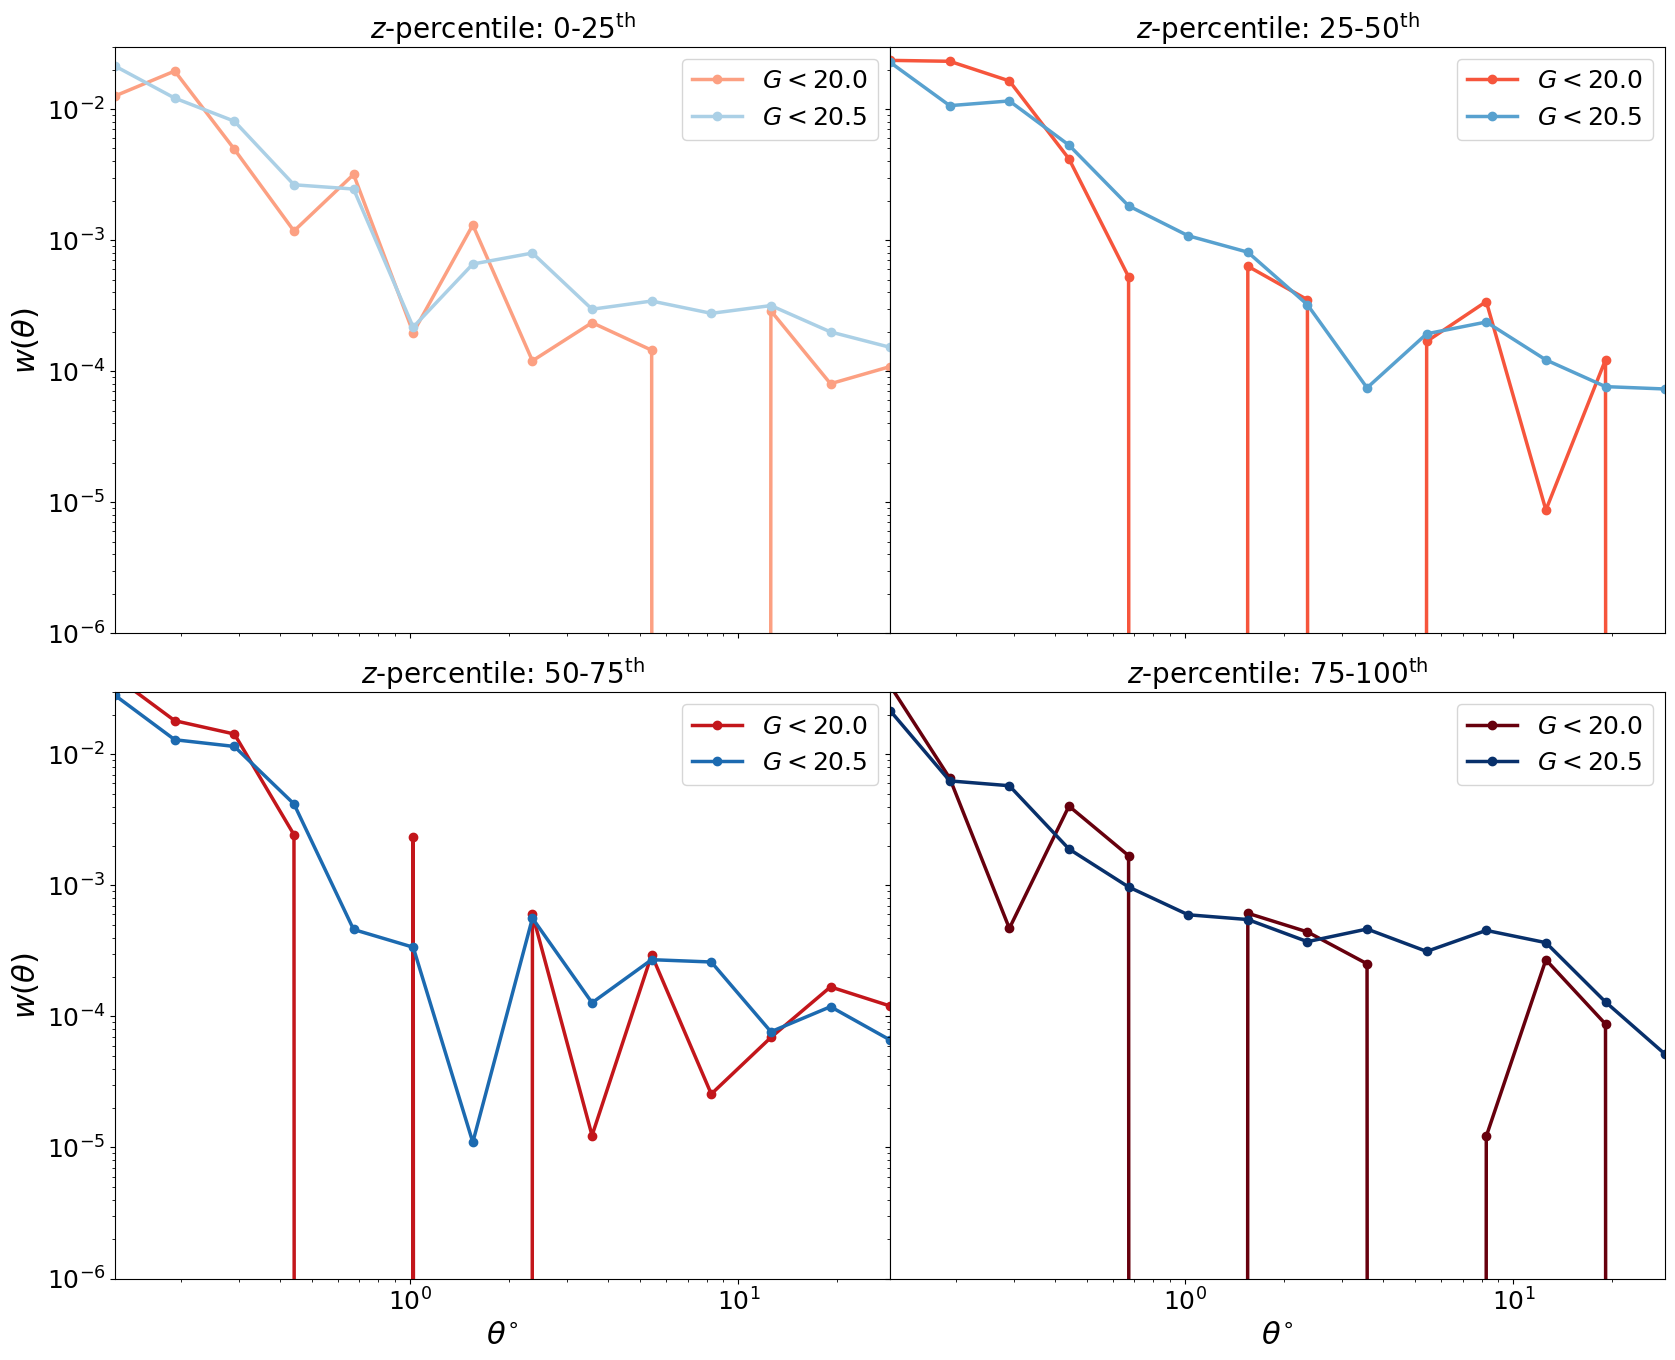

In [58]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)

for zbin, title in zip(zbin_array, ['0-25$^\mathrm{th}$', '25-50$^\mathrm{th}$', '50-75$^\mathrm{th}$', '75-100$^\mathrm{th}$']):
    ax1 = fig.add_subplot(gs[zbin])
    for G, cmap in zip([20.0, 20.5], cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][zbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[zbin])
        ax1.set_title('$z$-percentile: {}'.format(title))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.legend()
        if zbin>1:
            ax1.set_xlabel(r'$\theta^{\circ}$')
        else:
            ax1.set_xticklabels([])
        if zbin%2==0:
            ax1.set_ylabel(r"$w(\theta)$")
        else:
            ax1.set_yticklabels([])

plt.show()